In [ ]:
import pandas as pd
import numpy as np
import random
np.random.seed(42)
Data={'CustomerID': range(1,101),
      'Age':np.random.randint(18,80,size=100),
      'Gender':np.random.choice(['Male','Female'],size=100),
      'Country':np.random.choice(['America','French','Tunisia','Switzerland'],size=100),
      'ProductCategory':np.random.choice(['Electronics','Healthcare','Beauty','Books'],size=100),
      'PurchaseAmount':np.round(np.random.uniform(1,500,size=100),2),
      'Rating':np.random.choice([1,2,3,4,5,np.nan],size=100),
      'Review':np.random.choice(['bad','poor','average','good','excellent'],size=100),
      'PurchaseDate':pd.date_range(start='2023-01-01',periods=100,freq='D'),
      'LoyaltyMember':np.random.choice(['Yes','No'],size=100),



      }

In [ ]:
for col in ['Age', 'Rating']:
    df.loc[df.sample(frac=0.1).index, col] = np.nan

In [ ]:
df=pd.DataFrame(Data)

In [ ]:
df.head(20)

,CustomerID,Age,Gender,Country,ProductCategory,PurchaseAmount,Rating,Review,PurchaseDate,LoyaltyMember
0,1,56.0,Female,America,Electronics,392.88,3.0,good,2023-01-01,Yes
1,2,69.0,Female,Switzerland,Books,334.83,NaN,poor,2023-01-02,Yes
2,3,46.0,Female,Switzerland,Healthcare,290.76,5.0,excellent,2023-01-03,No
3,4,32.0,Female,French,Books,186.77,2.0,average,2023-01-04,Yes
4,5,60.0,Male,America,Healthcare,470.13,4.0,poor,2023-01-05,No
5,6,25.0,Female,Tunisia,Books,486.86,2.0,average,2023-01-06,No
6,7,78.0,Male,Tunisia,Beauty,142.68,NaN,bad,2023-01-07,Yes
7,8,38.0,Female,America,Books,153.38,3.0,poor,2023-01-08,Yes
8,9,56.0,Female,Tunisia,Beauty,243.32,1.0,excellent,2023-01-09,No
9,10,75.0,Male,Tunisia,Beauty,224.76,3.0,poor,2023-01-10,No


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Age,10
Gender,0
Country,0
ProductCategory,0
PurchaseAmount,0
Rating,21
Review,0
PurchaseDate,0
LoyaltyMember,0


In [ ]:
median_age=df['Age'].median()
mode_age=df['Age'].mode()[0]

In [ ]:
mode_rate=df['Rating'].mode()[0]

In [ ]:
mode_rate

5.0

In [ ]:
median_age

53.5

In [ ]:
mode_age

61.0

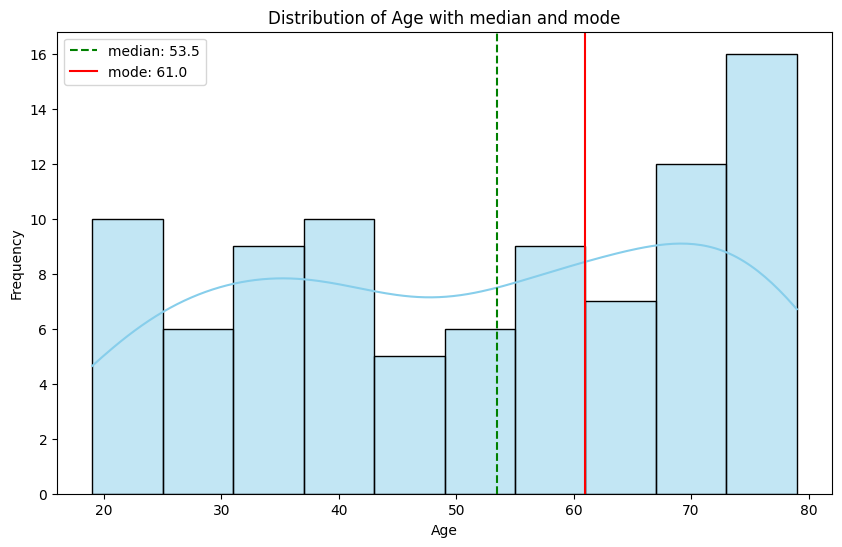

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
#plot the distribution of age
plt.figure(figsize=(10,6))
sns.histplot(df['Age'],kde=True,color='skyblue',bins=10)

#plot the median
plt.axvline(median_age,color='green',linestyle='--',label=f'median: {median_age}')

#plot the mode
plt.axvline(mode_age,color='red',linestyle='-',label=f'mode: {mode_age}')

#add title to label
plt.title('Distribution of Age with median and mode')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
df.Age.fillna(df.Age.median(),inplace=True)

In [ ]:
df.Rating.fillna(df.Rating.mode(),inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder
Label_Enc=LabelEncoder()
df['Gender']=Label_Enc.fit_transform(df['Gender'])
df['LoyaltyMember']=Label_Enc.fit_transform(df['LoyaltyMember'])

In [ ]:
df

,CustomerID,Age,Gender,Country,ProductCategory,PurchaseAmount,Rating,Review,PurchaseDate,LoyaltyMember
0,1,56.0,0,America,Electronics,392.88,3.0,good,2023-01-01,1
1,2,69.0,0,Switzerland,Books,334.83,NaN,poor,2023-01-02,1
2,3,46.0,0,Switzerland,Healthcare,290.76,5.0,excellent,2023-01-03,0
3,4,32.0,0,French,Books,186.77,2.0,average,2023-01-04,1
4,5,60.0,1,America,Healthcare,470.13,4.0,poor,2023-01-05,0
...,...,...,...,...,...,...,...,...,...,...
95,96,53.5,1,America,Books,482.66,2.0,poor,2023-04-06,0
96,97,35.0,0,America,Books,229.18,3.0,average,2023-04-07,0
97,98,43.0,1,Tunisia,Beauty,421.17,4.0,poor,2023-04-08,0
98,99,53.5,1,French,Electronics,98.00,5.0,poor,2023-04-09,0


In [ ]:
review_mapping={'poor':1,'bad':2,'average':3,'good':4,'excellent':5}
df['Review']=df['Review'].map(review_mapping)

In [ ]:
df

,CustomerID,Age,Gender,Country,ProductCategory,PurchaseAmount,Rating,Review,PurchaseDate,LoyaltyMember
0,1,56.0,0,America,Electronics,392.88,3.0,4,2023-01-01,1
1,2,69.0,0,Switzerland,Books,334.83,NaN,1,2023-01-02,1
2,3,46.0,0,Switzerland,Healthcare,290.76,5.0,5,2023-01-03,0
3,4,32.0,0,French,Books,186.77,2.0,3,2023-01-04,1
4,5,60.0,1,America,Healthcare,470.13,4.0,1,2023-01-05,0
...,...,...,...,...,...,...,...,...,...,...
95,96,53.5,1,America,Books,482.66,2.0,1,2023-04-06,0
96,97,35.0,0,America,Books,229.18,3.0,3,2023-04-07,0
97,98,43.0,1,Tunisia,Beauty,421.17,4.0,1,2023-04-08,0
98,99,53.5,1,French,Electronics,98.00,5.0,1,2023-04-09,0


In [ ]:
df=pd.get_dummies(df,columns=['Country','ProductCategory'],drop_first=True)

In [ ]:
df

,CustomerID,Age,Gender,PurchaseAmount,Rating,Review,PurchaseDate,LoyaltyMember,Country_French,Country_Switzerland,Country_Tunisia,ProductCategory_Books,ProductCategory_Electronics,ProductCategory_Healthcare
0,1,56.0,0,392.88,3.0,4,2023-01-01,1,False,False,False,False,True,False
1,2,69.0,0,334.83,NaN,1,2023-01-02,1,False,True,False,True,False,False
2,3,46.0,0,290.76,5.0,5,2023-01-03,0,False,True,False,False,False,True
3,4,32.0,0,186.77,2.0,3,2023-01-04,1,True,False,False,True,False,False
4,5,60.0,1,470.13,4.0,1,2023-01-05,0,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,53.5,1,482.66,2.0,1,2023-04-06,0,False,False,False,True,False,False
96,97,35.0,0,229.18,3.0,3,2023-04-07,0,False,False,False,True,False,False
97,98,43.0,1,421.17,4.0,1,2023-04-08,0,False,False,True,False,False,False
98,99,53.5,1,98.00,5.0,1,2023-04-09,0,True,False,False,False,True,False


In [ ]:
df['Purchase_Month']=df['PurchaseDate'].dt.month

In [ ]:
df

,CustomerID,Age,Gender,PurchaseAmount,Rating,Review,PurchaseDate,LoyaltyMember,Country_French,Country_Switzerland,Country_Tunisia,ProductCategory_Books,ProductCategory_Electronics,ProductCategory_Healthcare,Purchase_Month
0,1,56.0,0,392.88,3.0,4,2023-01-01,1,False,False,False,False,True,False,1
1,2,69.0,0,334.83,NaN,1,2023-01-02,1,False,True,False,True,False,False,1
2,3,46.0,0,290.76,5.0,5,2023-01-03,0,False,True,False,False,False,True,1
3,4,32.0,0,186.77,2.0,3,2023-01-04,1,True,False,False,True,False,False,1
4,5,60.0,1,470.13,4.0,1,2023-01-05,0,False,False,False,False,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,53.5,1,482.66,2.0,1,2023-04-06,0,False,False,False,True,False,False,4
96,97,35.0,0,229.18,3.0,3,2023-04-07,0,False,False,False,True,False,False,4
97,98,43.0,1,421.17,4.0,1,2023-04-08,0,False,False,True,False,False,False,4
98,99,53.5,1,98.00,5.0,1,2023-04-09,0,True,False,False,False,True,False,4


In [ ]:
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()
df['PurchaseAmount']=Scaler.fit_transform(df[['PurchaseAmount']])

In [ ]:
df

,CustomerID,Age,Gender,PurchaseAmount,Rating,Review,PurchaseDate,LoyaltyMember,Country_French,Country_Switzerland,Country_Tunisia,ProductCategory_Books,ProductCategory_Electronics,ProductCategory_Healthcare,Purchase_Month
0,1,56.0,0,1.042307,3.0,4,2023-01-01,1,False,False,False,False,True,False,1
1,2,69.0,0,0.630531,NaN,1,2023-01-02,1,False,True,False,True,False,False,1
2,3,46.0,0,0.317922,5.0,5,2023-01-03,0,False,True,False,False,False,True,1
3,4,32.0,0,-0.419728,2.0,3,2023-01-04,1,True,False,False,True,False,False,1
4,5,60.0,1,1.590278,4.0,1,2023-01-05,0,False,False,False,False,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,53.5,1,1.679159,2.0,1,2023-04-06,0,False,False,False,True,False,False,4
96,97,35.0,0,-0.118894,3.0,3,2023-04-07,0,False,False,False,True,False,False,4
97,98,43.0,1,1.242982,4.0,1,2023-04-08,0,False,False,True,False,False,False,4
98,99,53.5,1,-1.049415,5.0,1,2023-04-09,0,True,False,False,False,True,False,4


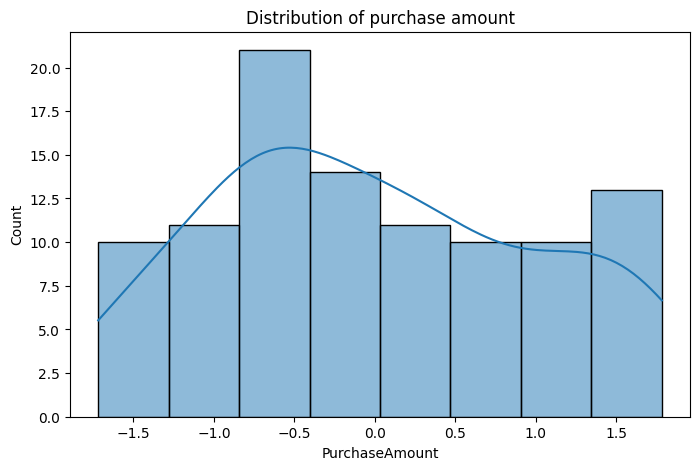

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['PurchaseAmount'],kde=True)
plt.title('Distribution of purchase amount')
plt.show()

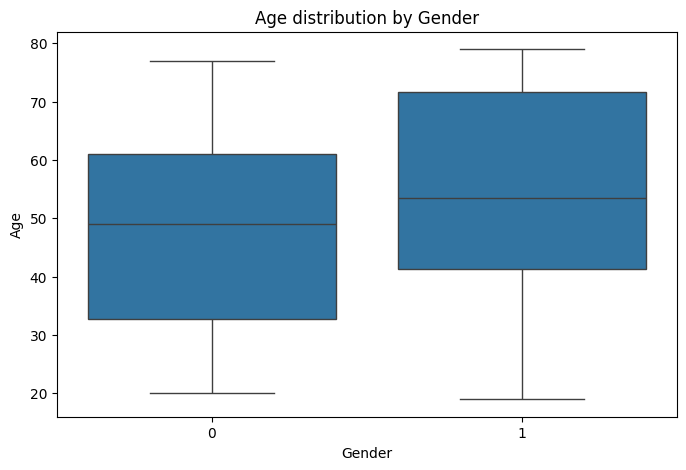

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Gender',y='Age',data=df)
plt.title('Age distribution by Gender')
plt.show()

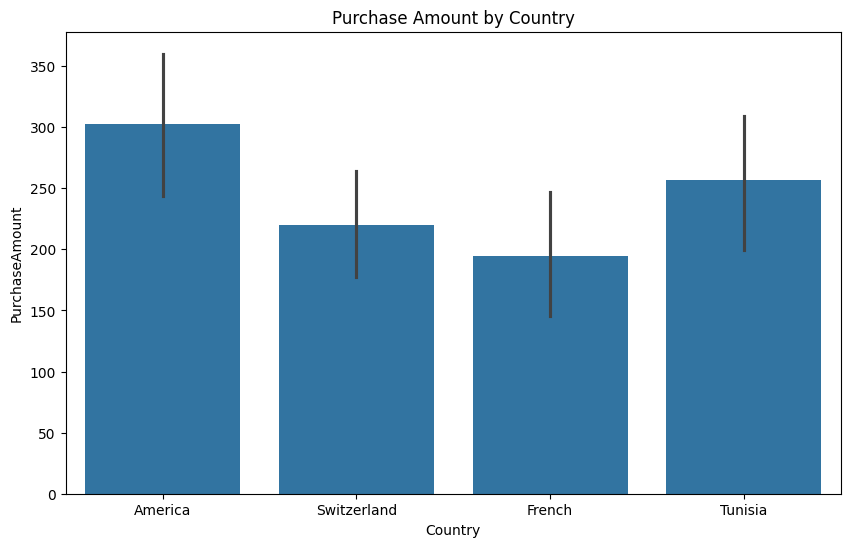

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(x='Country',y='PurchaseAmount',data=df)
plt.title('Purchase Amount by Country')
plt.show()